## Import dependencies

In [2]:
!pip install pandas numpy matplotlib scikit-learn xgboost torch
!python -m pip freeze > ../requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
telco = pd.read_csv('../data/raw/telco-churn.csv')

## Hiểu Dataset

In [5]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Dataset lớn bao nhiêu?

In [6]:
telco.shape

(7043, 21)

Có 7043 hàng và 21 cột

In [7]:
total_value = np.prod(telco.shape)
print(total_value)

147903


Có 147903 giá trị trong data set

### 2. Một Row đại diện cho cái gì?
1 row đại diện cho 1 khách hàng, thông tin khách hàng, gói mua của khách hàng và cuối cùng là churn của khách hàng

### 3. Target là column nào?

In [8]:
target_column = 'Churn'

Có 21 cột, trong đó 1 cột 'Churn' là target column, 20 cột còn lại là features

#### 4. Có những column nào?

In [9]:
telco.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [10]:
numerical_col = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
]
categorical_col = [
    'customerID',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Constract',
    'PaperlessBilling',
    'PaymentMethod',
    'TotalCharges',
]

Các column là:
- Identifier: customerID
- Numerical: SeniorCitizen, tenure, MonthlyCharges, TotalCharges
- Categorical: gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Constract, PaperlessBilling, PaymentMethod
- Target: Churn

### 5. Data type hiện tại của từng column?

Hiện tại có:
- int64: SeniorCitizen, tenure
- float64: MonthlyCharges
- str: gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Constract, PaperlessBilling, PaymentMethod, TotalCharges

In [11]:
pd.to_numeric(telco["TotalCharges"], errors="coerce")

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

### 6. Missing Values?

In [12]:
telco = telco.replace(["N/A", "NA", "?", "", "Unknown", " ", "-"],np.nan)
telco.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Có 11 missing values ở TotalCharges

In [13]:
telco[telco["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [14]:
telco.loc[telco["TotalCharges"].isna(),
       ["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


### 7. Duplicates?

In [15]:
num_unique_ID = telco['customerID'].nunique()
print(f"Có {telco.shape[0]} hàng và có {num_unique_ID} ID khác nhau")

Có 7043 hàng và có 7043 ID khác nhau


Không có duplicates ID

In [16]:
telco.duplicated().sum()

np.int64(0)

Không có duplicates về dòng

### 8. Target distribution?

In [17]:
telco[target_column].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Đây là 1 target imbalance, tỷ lệ của No là hơn 73%, còn lại Yes. Vì vậy nếu chỉ trả về No, model ngây thơ này có thể đạt accuracy khoảng 73%

### 9. Numerical phân bố như thế nào?

In [18]:
telco[numerical_col].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


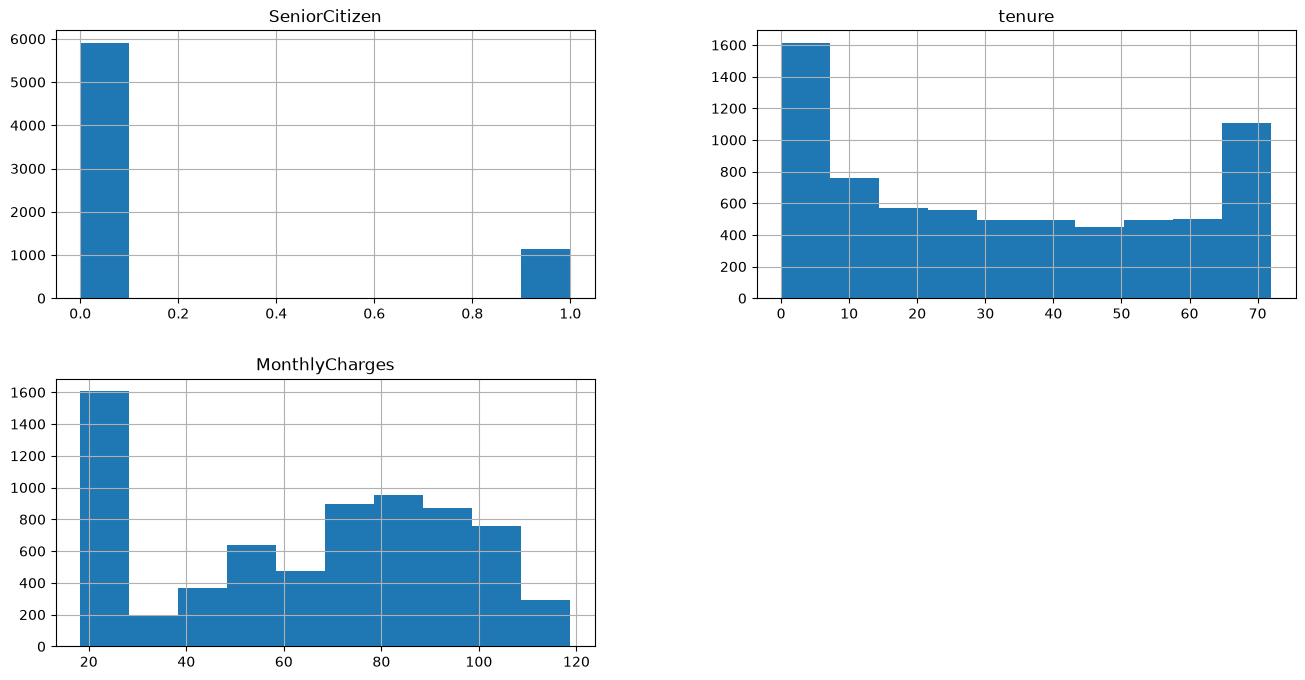

In [19]:
_ = telco.hist(figsize=(16, 8))

In [20]:
telco['tenure'].skew
# telco['MonthlyCharges'].skew

<bound method Series.skew of 0        1
1       34
2        2
3       45
4        2
        ..
7038    24
7039    72
7040    11
7041     4
7042    66
Name: tenure, Length: 7043, dtype: int64>

- Không có outlier, SeniorCitizen có gaps giữa 0 và 1 là do đây là binary variables
- Skew:
    - tenure có xu hướng lệch phải (skew > 0)
    - MonthlyCharges có xu hướng lệch trái (skew < 0)
- Range của của 3 là không bất thường

### 10. Có column đáng nghi nào không?

1. Identifier: Có tới 7043 khách hàng có ID khác nhau, tuy nhiên ID không phản ánh hàng vi hay các thông tin hoặc là có dẫn đến việc khách có churn hay không.
$\rightarrow$ Tốt cho việc tracking khách hàng, nhưng vô dụng trong việc làm features cho model vì có thể phải one-hot encoding 7043 dòng lận
2. TotalCharges, có MonthlyCharges và tenure. Có thể dùng phép nhân đơn giản để tính ra TotalCharges, vậy đây là 2 tập redundant mạnh hay có thể nói là 2 tập features chứa thông tin lẫn nhau, có thể bỏ bớt 1 cái cho dễ dàng.
3. Nên kiểm tra các Columns gây data leakage
4. Kiểm tra các columns khi deploy thì nó có xuất hiện trong tình huống thật hay không.
5. Đối với SeniorCitizen thì nên đối xử với nó như là binary categorical variable. Nó không phải là continuous numeric feature.

### Ngoài lề

In [21]:
telco.nunique().sort_values()

Churn                  2
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PaperlessBilling       2
PhoneService           2
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
DeviceProtection       3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6530
customerID          7043
dtype: int64

IDs: customerID
Codes: SeniorCitizen
high-cardinality categorical variables: 

### Investigation A 

In [22]:
telco[telco['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [23]:
telco.loc[telco['TotalCharges'].isna(), ['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Điểm chung là tenure đều là 0

In [24]:
telco.loc[telco["tenure"] == 0, ["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


Có thể khẳng định, TotalCharges bị missing là do tenure của khách hàng là 0

### Investigation B

In [25]:
estimate_value = telco['tenure'] * telco['MonthlyCharges']
pd.DataFrame(estimate_value)

,0
0,29.85
1,1936.30
2,107.70
3,1903.50
4,141.40
...,...
7038,2035.20
7039,7430.40
7040,325.60
7041,297.60


In [28]:
telco["TotalCharges"]

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str

Nhìn chung là không giống nhau hoàn toàn, có sai số cũng khá lớn

## Chốt

`customerID` loại khỏi model; `SeniorCitizen` xem là binary categorical; `TotalCharges` convert sang numeric và các giá trị thiếu do `tenure = 0` có thể điền bằng `0`; dataset bị class imbalance khoảng 73/27; chưa thấy duplicate; chưa thấy dấu hiệu leakage rõ ràng.